In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


## Representing Graphs: 3 Ways to Store a Graph

Before running any algorithm, you must choose a data structure (because you need to store the graph). The right choice depends on the graph's **size**, **density**, and what **operations** you need to perform fast.

### Summary

| Property           | Adjacency Matrix        | Adjacency List                     | Adjacency Dictionary              |
|-------------------|------------------------|------------------------------------|-----------------------------------|
| Space             | O(V²)                  | O(V + E)                           | O(V + E)                          |
| Edge lookup       | O(1)                   | O(degree)                          | O(1) average                      |
| Iterate neighbors | O(V)                   | O(degree)                          | O(degree)                         |
| Best for          | Dense graphs, fast lookups | Sparse graphs (most real-world) | Fast lookups with flexible structure |
| Worst for         | Large sparse graphs    | Edge weight matrix                 | Slight overhead due to hashing     |


### (1) Adjacency Matrix

An **N × N** matrix where `M[i][j] = 1` (or the edge weight) if an edge exists from node i to node j, otherwise 0.

- Edge existence check in **O(1)**
- Wastes **O(V²)** memory — 1 million nodes = 10¹² entries

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251028181828547875/1-.webp" width="500"/>
</p>

<p align="center">
  <em>Adjacency Matrix. Source: GeeksforGeeks</em><br>
</p>

```python
# 4 nodes: You=0, Alice=1, Bob=2, Charlie=3
adj_matrix = [
    [0, 1, 0, 1],  # You connects to Alice and Charlie
    [1, 0, 1, 1],  # Alice connects to You, Bob, Charlie
    [0, 1, 0, 0],  # Bob connects to Alice
    [1, 1, 0, 0],  # Charlie connects to You and Alice
]
```

### (2) Adjacency List

Each node stores a **list of its neighbors**. Only edges that exist take up memory.

- Space efficient: **O(V + E)** - far more efficient for sparse graphs (most real-world graphs have far fewer edges than the maximum possible).

- Fast neighbor iteration — most graph algorithms use this
- Checking if a specific edge exists requires scanning the neighbor list: **O(degree)**

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251028181956953251/file.webp" width="500"/>
</p>

<p align="center">
  <em>Adjacency List. Source: GeeksforGeeks</em><br>
</p>


```python
graph = {
    'You':     ['Alice', 'Charlie'],
    'Alice':   ['You', 'Bob', 'Charlie'],
    'Bob':     ['Alice', 'David'],
    'Charlie': ['You', 'Alice', 'Eve'],
    'David':   ['Bob'],
    'Eve':     ['Bob', 'Charlie'],
}
```
Real-world graphs use libraries like [NetworkX](https://networkx.org/) (Python), [igraph](https://igraph.org/), or graph databases like [Neo4j](https://neo4j.com/) for billion-edge scale.

### (3) Adjacency Dictionary

An **adjacency dictionary** is a dict-of-dicts. It stores each node and its neighbors as **key–value pairs**.

- Outer key → node  
- Inner key → neighbor  
- Inner value → weight (or 1 if unweighted)

Some key advantages:
- Fast edge lookup → average **O(1)**  
- Naturally supports **weighted graphs**  
- Flexible for storing extra information (distance, cost, frequency)

> **Intuition**: *Adjacency List* = simple neighbors ; *Adjacency Dictionary* = neighbors + extra information

```python
graph_weighted = {
    'You':     {'Alice': 2, 'Charlie': 1},
    'Alice':   {'You': 2, 'Bob': 3, 'Charlie': 2},
    'Bob':     {'Alice': 3, 'David': 4},
    'Charlie': {'You': 1, 'Alice': 2, 'Eve': 5},
    'David':   {'Bob': 4},
    'Eve':     {'Bob': 2, 'Charlie': 5},
}

```

Compared to an adjacency list (dict of lists):

| Operation | Adj. List | Adj. Dictionary |
|-----------|-----------|-----------------|
| Space | O(V + E) | O(V + E) |
| Check if edge (u,v) exists | O(degree(u)) | **O(1)** |
| Get weight of edge (u,v) | O(degree(u)) | **O(1)** |
| Add edge | O(1) append | O(1) assign |
| Remove edge | O(degree) | **O(1)** del |
| Iterate neighbors of u | O(degree) | O(degree) |

> This is the representation used internally by **NetworkX** (`G._adj`) and by most production graph libraries.

Variants:
- **Unweighted** — inner value is `1` (or `{}`) — just tracks existence
- **Weighted** — inner value is a number (distance, cost, probability)
- **Attributed** — inner value is a dict holding multiple properties per edge



=== Adjacency Matrix ===
         You  Alice  Bob  Charlie  David  Eve
You        0      1    0        1      0    0
Alice      1      0    1        1      0    0
Bob        0      1    0        0      1    1
Charlie    1      1    0        0      0    1
David      0      0    1        0      0    0
Eve        0      0    1        1      0    0


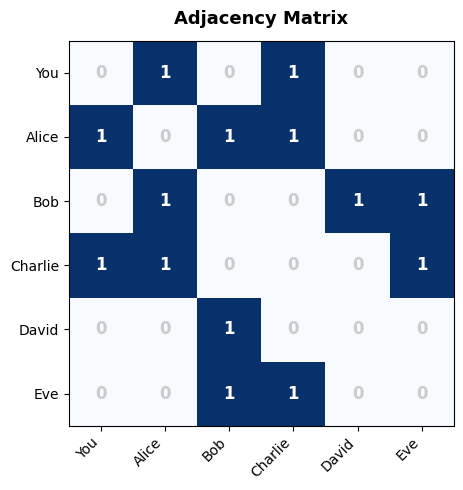


Matrix size  : 6×6 = 36 cells
Non-zero     : 14 (edges × 2 for undirected)
Sparsity     : 61.1%  ← most cells are wasted zeros


In [ ]:
# ── Adjacency Matrix ─────────────────────────────────────────────────────────
node_list = ['You', 'Alice', 'Bob', 'Charlie', 'David', 'Eve']
n = len(node_list)
idx = {name: i for i, name in enumerate(node_list)}

adj_matrix = np.zeros((n, n), dtype=int)
for u, v in edges:
    adj_matrix[idx[u]][idx[v]] = 1
    adj_matrix[idx[v]][idx[u]] = 1   # undirected

df_matrix = pd.DataFrame(adj_matrix, index=node_list, columns=node_list)
print("=== Adjacency Matrix ===")
print(df_matrix)

# Visualise as heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(adj_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(node_list, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(node_list, fontsize=10)
for i in range(n):
    for j in range(n):
        ax.text(j, i, adj_matrix[i][j], ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if adj_matrix[i][j] else '#cccccc')
ax.set_title('Adjacency Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

sparsity = 1 - (adj_matrix.sum() / adj_matrix.size)
print(f"\nMatrix size  : {n}×{n} = {n*n} cells")
print(f"Non-zero     : {int(adj_matrix.sum())} (edges × 2 for undirected)")
print(f"Sparsity     : {sparsity:.1%}  ← most cells are wasted zeros")

In [ ]:
# ── Adjacency List ───────────────────────────────────────────────────────────
adj_list = {node: [] for node in node_list}

for u, v in edges:
    adj_list[u].append(v)
    adj_list[v].append(u)   # undirected

print("=== Adjacency List ===")
for node, neighbors in adj_list.items():
    print(f"  {node:8s} → {neighbors}")

total_entries = sum(len(v) for v in adj_list.values())
print(f"\nTotal entries stored: {total_entries}  (= 2×|E| = 2×{len(edges)})")
print(f"vs adjacency matrix : {n*n} entries")
print(f"Memory saving       : {1 - total_entries/(n*n):.1%} fewer entries")

=== Adjacency List ===
  You      → ['Alice', 'Charlie']
  Alice    → ['You', 'Bob', 'Charlie']
  Bob      → ['Alice', 'David', 'Eve']
  Charlie  → ['You', 'Alice', 'Eve']
  David    → ['Bob']
  Eve      → ['Bob', 'Charlie']

Total entries stored: 14  (= 2×|E| = 2×7)
vs adjacency matrix : 36 entries
Memory saving       : 61.1% fewer entries


In [ ]:
# ── Adjacency Dictionary — three flavours ────────────────────────────────────

# 1. Unweighted (value = 1, just marks edge existence)
adj_dict_unweighted = {
    'You':     {'Alice': 1, 'Charlie': 1},
    'Alice':   {'You': 1, 'Bob': 1, 'Charlie': 1},
    'Bob':     {'Alice': 1, 'David': 1, 'Eve': 1},
    'Charlie': {'You': 1, 'Alice': 1, 'Eve': 1},
    'David':   {'Bob': 1},
    'Eve':     {'Bob': 1, 'Charlie': 1},
}

# 2. Weighted (value = edge weight)
adj_dict_weighted = {
    'You':     {'Alice': 0.9, 'Charlie': 0.7},
    'Alice':   {'You': 0.9, 'Bob': 0.5, 'Charlie': 0.8},
    'Bob':     {'Alice': 0.5, 'David': 0.6, 'Eve': 0.4},
    'Charlie': {'You': 0.7, 'Alice': 0.8, 'Eve': 0.3},
    'David':   {'Bob': 0.6},
    'Eve':     {'Bob': 0.4, 'Charlie': 0.3},
}

# 3. Attributed (value = dict with multiple properties per edge)
adj_dict_attributed = {
    'You':   {'Alice':   {'weight': 0.9, 'since': 2023, 'context': 'orientation'},
              'Charlie': {'weight': 0.7, 'since': 2023, 'context': 'class'}},
    'Alice': {'You':     {'weight': 0.9, 'since': 2023, 'context': 'orientation'},
              'Bob':     {'weight': 0.5, 'since': 2023, 'context': 'introduction'},
              'Charlie': {'weight': 0.8, 'since': 2023, 'context': 'class'}},
    # ... (truncated for brevity)
}

# ── O(1) operations ───────────────────────────────────────────────────────────
g = adj_dict_weighted

print("=== O(1) edge operations ===")
print(f"Edge (You, Alice) exists?    {'Alice' in g['You']}")          # O(1)
print(f"Edge (You, David) exists?    {'David' in g['You']}")          # O(1)
print(f"Weight of (Alice, Bob):      {g['Alice']['Bob']}")             # O(1)
print(f"Degree of Alice:             {len(g['Alice'])}")               # O(1)

print("\n=== Adding and removing edges ===")
g['David']['Eve'] = 0.2          # add a new edge        O(1)
print(f"After adding David-Eve:      {list(g['David'].keys())}")

del g['David']['Eve']            # remove it             O(1)
print(f"After removing David-Eve:    {list(g['David'].keys())}")

print("\n=== Iterating neighbors ===")
for neighbor, weight in g['Alice'].items():           # O(degree)
    print(f"  Alice → {neighbor:8s}  weight={weight}")

=== O(1) edge operations ===
Edge (You, Alice) exists?    True
Edge (You, David) exists?    False
Weight of (Alice, Bob):      0.5
Degree of Alice:             3

=== Adding and removing edges ===
After adding David-Eve:      ['Bob', 'Eve']
After removing David-Eve:    ['Bob']

=== Iterating neighbors ===
  Alice → You       weight=0.9
  Alice → Bob       weight=0.5
  Alice → Charlie   weight=0.8
